# Data Clustering

## 1. Import Libraries

In [1]:
import importlib
import sys, os

# Ensure project root is on path
sys.path.insert(0, os.path.abspath(".."))

import src.code.class_pipeline_functions as cpf
import src.code.io_utils as io

importlib.reload(cpf)
importlib.reload(io)

import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.decomposition import PCA
from itertools import combinations
import matplotlib.patches as mpatches
import umap.umap_ as umap_module

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 1000)

ABT_OUT_PATH  = "../data/prepared/abt.parquet"

## 2. Multiple Perspective Approach

 **Approach:** K-Means clustering applied independently across three business perspectives, 
 followed by hierarchical merging of the resulting cluster combinations.

In [2]:
customer = io.load("../data/prepared/customer.parquet")

[LOAD] ../data/prepared/customer.parquet | shape: (134222, 45)


In [3]:
# Perspective 1 — Contract Financial Profile
p1_cols = ['N_CONTRACTS', 'TOTAL_MTFINO', 
           'TOTAL_MENSALIDADE', 'MEDIAN_DURDEG'] #'MT_MENSAL_MEDIAN'

# Perspective 2 — Risk & External Credit Behaviour
p2_cols = ['MAX_RANGPRO', 'MAX_RANGCLI',"MAX_RISKA", # should we remove MAX_RISKA?
           'ALLBD_IDADE_MEAN__N',
           'COUNT_CL_MEDIAN', 'COUNT_AUTO_MEDIAN', 'COUNT_TOTAL_MEDIAN',
           'DIVIDAS_TOTAL_MEDIAN',
           'MONTVENC_TOTAL_LOG', 'RISK_EVER',  'RISK_RECENT'  
            ] 

# Perspective 3 — Cetelem History
p3_cols = ['CLIENT_SENIORITY_YEARS', 'YEARS_SINCE_LAST_CONTRACT', 
           'ALLBD_N_Dossiers__N']

# Profiling variables — not used in clustering, used for segment description only
profiling_cols = [
    # Sociodemographic
    'sdem_age', 'CSP', 'NBENF',
    # Contract antiquity (limited to 2024-2025 window — interpret with caution)
    'ALLBD_IDADE_MEAN__N',
    # Historical risk
    'RISK_TOTAL',
    # Family situation dummies (sdem_SITFAM_F excluded per Cetelem guidance)
    'sdem_SITFAM_D', 'sdem_SITFAM_P', 'sdem_SITFAM_S',
    'sdem_SITFAM_U', 'sdem_SITFAM_Unknown',
    'sdem_SITFAM_V', 'sdem_SITFAM_X',
    # Habitat dummies
    'sdem_HABITAT_A', 'sdem_HABITAT_E', 'sdem_HABITAT_F',
    'sdem_HABITAT_L', 'sdem_HABITAT_O', 'sdem_HABITAT_P',
    'sdem_HABITAT_Unknown', 'sdem_HABITAT_X',
    # Sum of monthly installments paid by the client (66% missing values that were imputed to 0)
    'MT_MENSAL_MEDIAN',
    'MEDIAN_RESSO',
    'EXTERNAL_TO_CETELEM'
]

In [4]:
perspectives = {
    'P1_Financial': p1_cols,
    'P2_Risk': p2_cols,
    'P3_History': p3_cols
}

### 2.1 N-Clusters

Determining the optimal number of clusters for each perspective using two complementary methods:

- **Elbow Method**: identifies the point of diminishing returns in inertia reduction
- **Silhouette Score**: measures how well-separated clusters are (range: -1 to 1)

c:\Users\Asus\anaconda3\envs\Fall2526\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


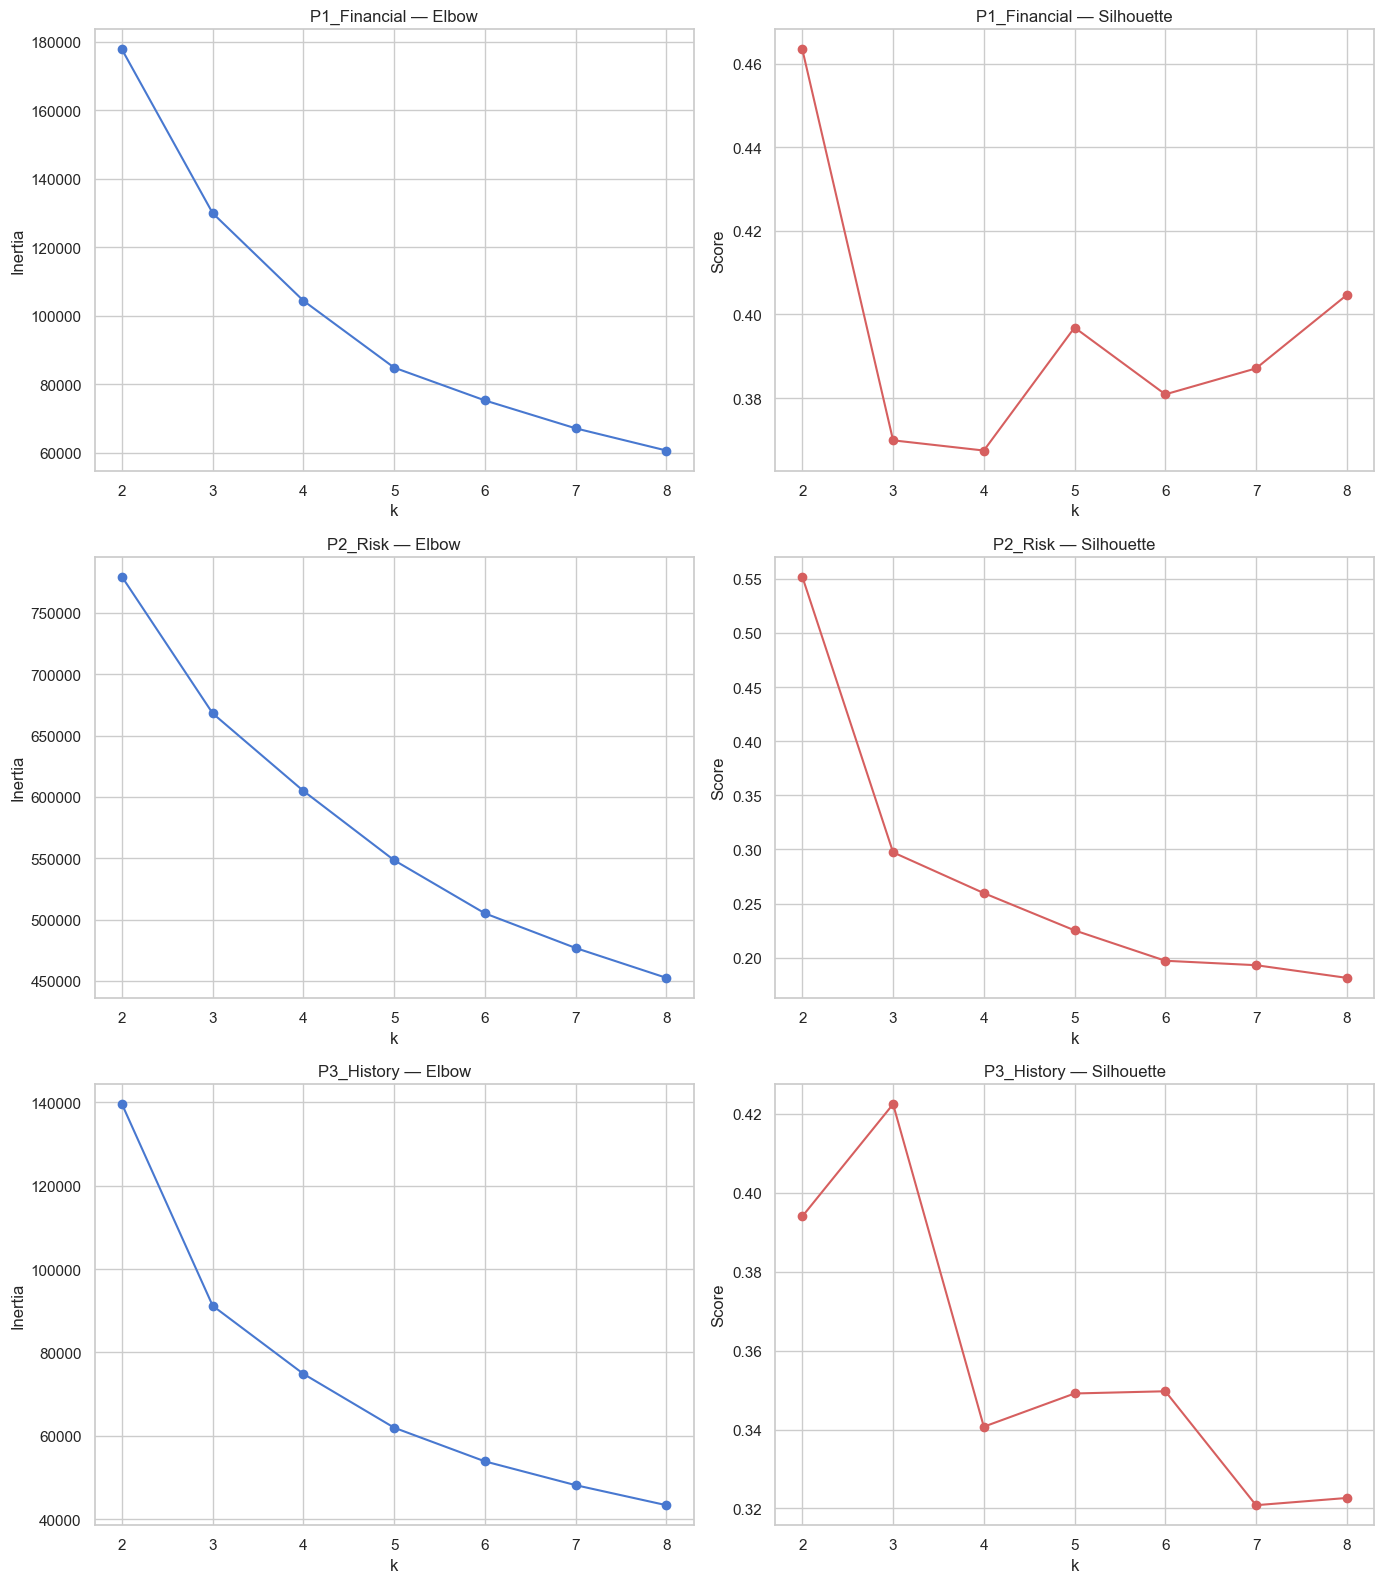

In [5]:
fig, axes = plt.subplots(len(perspectives), 2, figsize=(14, 16))

for idx, (name, cols) in enumerate(perspectives.items()):
    X = customer[cols].dropna()
    inertias, silhouettes = [], []
    K = range(2, 9)
    
    for k in K:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X, km.labels_, sample_size=10000))
    
    axes[idx, 0].plot(K, inertias, 'bo-')
    axes[idx, 0].set_title(f'{name} — Elbow')
    axes[idx, 0].set_xlabel('k')
    axes[idx, 0].set_ylabel('Inertia')
    
    axes[idx, 1].plot(K, silhouettes, 'ro-')
    axes[idx, 1].set_title(f'{name} — Silhouette')
    axes[idx, 1].set_xlabel('k')
    axes[idx, 1].set_ylabel('Score')

plt.tight_layout()
plt.show()

**Elbow & Silhouette Analysis**

*P1: Financial Profile*

The elbow curve shows a gradual decline without a sharp bend. While k=2 maximises mathematical separation, it produces only a binary split ("high value" vs "rest") which lacks business interpretability. 
We selected k=3 as it provides three distinct financial  profiles (short-duration contracts, base clients, and high-volume clients).

*P2: Risk & External Credit Behaviour*

The elbow curve shows a clear inflection point at k=3, after which the rate of inertia reduction slows considerably. The silhouette score confirms this, dropping sharply from 0.55 at k=2 to 0.30 at k=3, and continuing to decline monotonically thereafter. Both methods agree on k=3.

*P3: Cetelem History*

The elbow curve shows a visible bend at k=3, and the silhouette score reaches its global peak at k=3 before dropping sharply to 0.34 at k=4. Both methods agree on k=3, producing three interpretable history profiles.

> NOTE: We considered silhouette scores in the range 0.37–0.42 reasonable for real-world financial data where natural cluster separation is limited by data quality and the 2024–2025 observation window. The final k selection prioritises business interpretability over mathematical optimality.

In [6]:
perspectives = {
    'P1_Financial': {'cols': p1_cols, 'k': 3},
    'P2_Risk':      {'cols': p2_cols, 'k': 3}, 
    'P3_History':   {'cols': p3_cols, 'k': 3},
}

### 2.2 K-means Clustering

In [7]:
for name, config in perspectives.items():
    cols = config['cols']
    k    = config['k']
    
    print(f"\n{'='*50}", flush=True)
    print(f"{name} | k={k} | {len(cols)} variáveis", flush=True)
    print(f"{'='*50}", flush=True)
    
    # Verificar nulos
    n_nulls = customer[cols].isnull().sum().sum()
    if n_nulls > 0:
        print(f"  {n_nulls} nulos encontrados — a remover linhas", flush=True)
    
    X = customer[cols].dropna()
    
    # Fit KMeans
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    
    # Guardar labels no dataframe
    cluster_col = f'cluster_{name}'
    customer.loc[X.index, cluster_col] = labels
    
    # Distribuição dos clusters
    dist = customer[cluster_col].value_counts().sort_index()
    print("\nDistribuição dos clusters:", flush=True)
    for cluster, count in dist.items():
        pct = count / len(X) * 100
        print(f"  Cluster {int(cluster)}: {count:>6} clientes ({pct:.1f}%)", flush=True)
    
    # Centroides — logo aqui para não perder output
    print("\nCentroides:", flush=True)
    centroids = customer.dropna(subset=[cluster_col]).groupby(cluster_col)[cols].mean().round(3)
    print(centroids.T.to_string(), flush=True)
    
    # Inércia final
    print(f"\nInércia final: {km.inertia_:,.0f}", flush=True)
    print(flush=True)
    sys.stdout.flush()

print("\n Clustering concluído para todas as perspetivas")
print(f"Colunas adicionadas: {[f'cluster_{p}' for p in perspectives.keys()]}")


P1_Financial | k=3 | 4 variáveis

Distribuição dos clusters:
  Cluster 0:  45542 clientes (33.9%)
  Cluster 1:  25987 clientes (19.4%)
  Cluster 2:  62693 clientes (46.7%)

Centroides:
cluster_P1_Financial  0.000  1.000  2.000
N_CONTRACTS           0.167  0.627  0.086
TOTAL_MTFINO         -0.336  1.675  0.120
TOTAL_MENSALIDADE    -0.102  1.666 -0.044
MEDIAN_DURDEG        -1.238  0.132  0.104

Inércia final: 129,955


P2_Risk | k=3 | 11 variáveis

Distribuição dos clusters:
  Cluster 0:  26745 clientes (19.9%)
  Cluster 1:  82918 clientes (61.8%)
  Cluster 2:  24559 clientes (18.3%)

Centroides:
cluster_P2_Risk       0.000  1.000  2.000
MAX_RANGPRO           0.119  0.104  0.110
MAX_RANGCLI           0.078  0.093  0.145
MAX_RISKA             0.139  0.025  0.022
ALLBD_IDADE_MEAN__N   0.067  0.185  0.106
COUNT_CL_MEDIAN       1.007 -0.061  2.048
COUNT_AUTO_MEDIAN     0.544  0.539  0.474
COUNT_TOTAL_MEDIAN    0.130 -0.277  0.705
DIVIDAS_TOTAL_MEDIAN  0.410  0.200  0.938
MONTVENC_TOTAL_LOG 

Each perspective underwent multiple iterations of feature selection, scaling validation, and outlier treatment to ensure no single variable artificially dominated cluster separation and that resulting distributions were meaningful and representative of real client behaviour.

**P1, Contract Financial Profile | k=3 | 4 variables**

- Cluster 0 (33.9%) — short-duration, low-value contracts
- Cluster 1 (19.4%) — multiple high-value contracts, most profitable
- Cluster 2 (46.7%) — standard base client, all values near zero

> `MEDIAN_RESSO` was tested in this perspective but degraded cluster quality: the silhouette score dropped and the elbow lost its inflection point, indicating that the income variable was creating a dominant binary split ("has income / no income") instead of a meaningful financial segments. It was moved to profiling only.

---

**P2, Risk & External Credit Behaviour | k=3 | 11 variables**

- Cluster 0 (19.9%) — significant overdue amounts (`MONTVENC=6.30`), recent delinquency signals (`RISK_EVER=0.38`, `RISK_RECENT=0.19`)
- Cluster 1 (61.8%) — healthy clients, no risk indicators
- Cluster 2 (18.3%) — high external consumer credit exposure, 
  potential competitor risk

> This perspective required the most iterations. Key decisions: `MONTVENC_TOTAL_LOG` treated with log1p transform (75%+ zeros, IQR=0); `RISK_EVER` and `RISK_RECENT` added from the 24-month risk sequence; we did multiple combination searches to prevent binary variables from dominating cluster separation.

---

**P3, Cetelem History | k=3 | 3 variables**

- Cluster 0 (54.7%) — recent clients, short history within observation window
- Cluster 1 (30.1%) — long-tenure clients with no recent contract, potential dormant churners
- Cluster 2 (15.2%) — most engaged clients, highest dossier count (`ALLBD_N_Dossiers__N = 1.68`)

> Given the 2024–2025 data window, seniority and recency metrics reflect relative position within the dataset period rather than true customer lifetime.

### 2.3 Merge clusters with Hierarchical Clustering

Each customer receives a combined label `P1_P2_P3` (e.g. `0_0_2`) from the three K-Means runs.  
Ward linkage hierarchical clustering is then applied over the centroids of each combination to identify natural groupings and reduce to a final set of actionable segments.


In [8]:
# Check individual cluster distributions
for col in ['cluster_P1_Financial', 'cluster_P2_Risk', 'cluster_P3_History']:
    print(f"\n{col}:")
    dist = customer[col].value_counts(normalize=True).sort_index()
    for c, pct in dist.items():
        print(f"  Cluster {int(c)}: {pct*100:.1f}%")

# Check P2 specifically — likely very imbalanced
print("\nP2 centroids:")
print(customer.groupby('cluster_P2_Risk')[p2_cols].mean().round(3).T)


cluster_P1_Financial:
  Cluster 0: 33.9%
  Cluster 1: 19.4%
  Cluster 2: 46.7%

cluster_P2_Risk:
  Cluster 0: 19.9%
  Cluster 1: 61.8%
  Cluster 2: 18.3%

cluster_P3_History:
  Cluster 0: 54.7%
  Cluster 1: 30.1%
  Cluster 2: 15.2%

P2 centroids:
cluster_P2_Risk       0.000  1.000  2.000
MAX_RANGPRO           0.119  0.104  0.110
MAX_RANGCLI           0.078  0.093  0.145
MAX_RISKA             0.139  0.025  0.022
ALLBD_IDADE_MEAN__N   0.067  0.185  0.106
COUNT_CL_MEDIAN       1.007 -0.061  2.048
COUNT_AUTO_MEDIAN     0.544  0.539  0.474
COUNT_TOTAL_MEDIAN    0.130 -0.277  0.705
DIVIDAS_TOTAL_MEDIAN  0.410  0.200  0.938
MONTVENC_TOTAL_LOG    6.300  0.053  0.094
RISK_EVER             0.383  0.039  0.032
RISK_RECENT           0.188  0.016  0.011


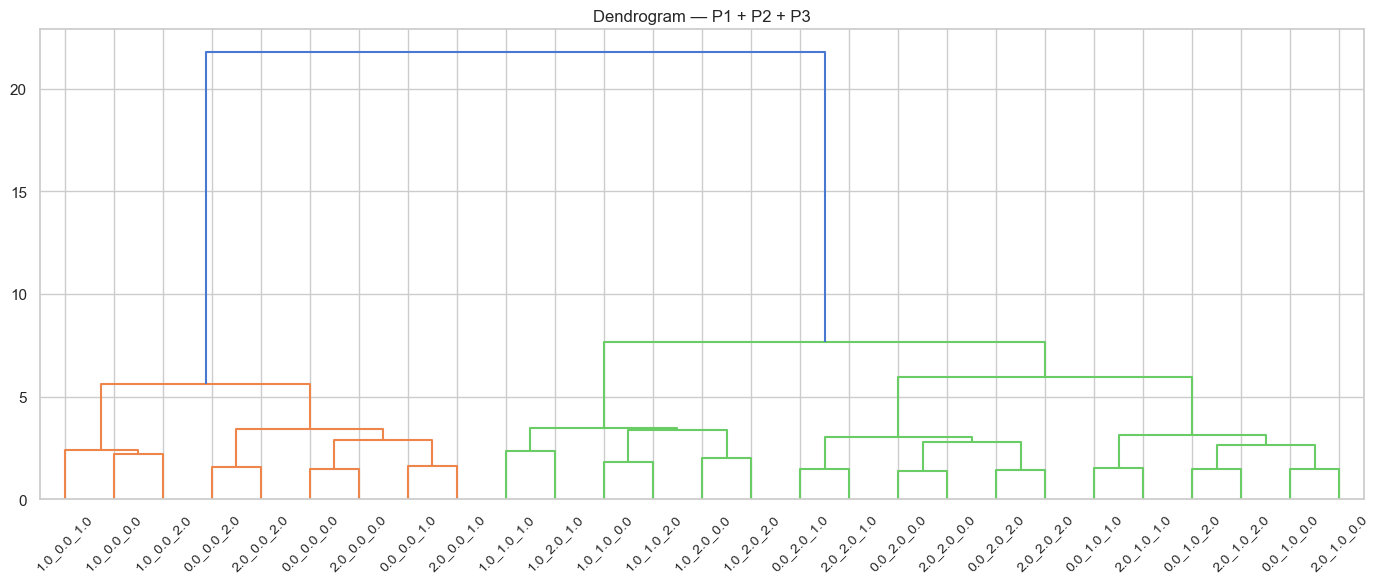

segment_final
1    26745
2    21098
3    18766
4    67613
Name: count, dtype: int64


In [9]:
# ── Create combined label ─────────────────────────────────────────────────────
customer['cluster_P1_P2_P3'] = (
    customer['cluster_P1_Financial'].astype(str) + '_' +
    customer['cluster_P2_Risk'].astype(str) + '_' +
    customer['cluster_P3_History'].astype(str)
)

# ── Hierarchical clustering on centroids ──────────────────────────────────────
all_cols = p1_cols + p2_cols + p3_cols
centroids = customer.groupby('cluster_P1_P2_P3')[all_cols].mean()

Z = linkage(centroids, method='ward')

# Dendrogram
plt.figure(figsize=(14, 6))
dendrogram(Z, labels=centroids.index.tolist(), leaf_rotation=45, leaf_font_size=10)
plt.title('Dendrogram — P1 + P2 + P3')
plt.tight_layout()
plt.show()

# ── Final segmentation — adjust n_final after seeing dendrogram ───────────────
n_final = 4

customer['segment_final'] = customer['cluster_P1_P2_P3'].map(
    dict(zip(centroids.index, fcluster(Z, n_final, criterion='maxclust')))
)

print(customer['segment_final'].value_counts().sort_index())

Each client received a combined label P1_P2_P3 from the three K-Means runs (up to 27 combinations). We applied ward linkage hierarchical clustering over the centroids of each combination to reduce to a final set of actionable business segments.

The dendrogram reveals a structure with two branches: the orange branch isolates all high-risk combinations (P2 Cluster 0), confirming that clients with significant overdue amounts are genuinely distinct from all others. The green branch subdivides the remaining low-risk combinations by financial profile and Cetelem history.

The dendrogram was cut at n=4, producing four actionable segments. Cutting deeper yielded segments below 2% of the client base, which are not operationally useful for Cetelem.


## 3. Profiling

With the four final segments defined, we now characterise each 
group across three dimensions:

- **Clustering variables**: centroid values for all P1, P2 and P3 features, normalised per variable to highlight relative differences across segments
- **Continuous profiling**: sociodemographic variables excluded from clustering (`sdem_age`, `CSP`, `NBENF`, `MEDIAN_RESSO`, `EXTERNAL_TO_CETELEM`)
- **Categorical profiling**: family situation (`SITFAM`) and habitat type (`HABITAT`), both used for segment description only

The goal of this section is to build a complete business portrait of each segment (who they are, how they behave financially, and where they stand in their contract lifecycle) to support targeted retention strategies.

In [10]:
all_feature_cols = p1_cols + p2_cols + p3_cols

sitfam_cols = ['sdem_SITFAM_D', 'sdem_SITFAM_P', 'sdem_SITFAM_S',
               'sdem_SITFAM_U', 'sdem_SITFAM_Unknown',
               'sdem_SITFAM_V', 'sdem_SITFAM_X']

habitat_cols = ['sdem_HABITAT_A', 'sdem_HABITAT_E', 'sdem_HABITAT_F',
                'sdem_HABITAT_L', 'sdem_HABITAT_O', 'sdem_HABITAT_P',
                'sdem_HABITAT_Unknown', 'sdem_HABITAT_X']

continuous_profiling = ['sdem_age', 'CSP', 'NBENF', 'MEDIAN_RESSO',
                        'ALLBD_IDADE_MEAN__N', 'RISK_TOTAL',
                        'EXTERNAL_TO_CETELEM']

seg_col = 'segment_final'
valid = customer.dropna(subset=[seg_col])
segments = sorted(valid[seg_col].unique())


In [11]:
print("=" * 60)
print("SEGMENT DISTRIBUTION")
print("=" * 60)
for s in segments:
    count = (valid[seg_col] == s).sum()
    pct = count / len(valid) * 100
    print(f"  Segment {int(s)}: {count:>8,} ({pct:.1f}%)")

# feature centroids
print("\n" + "=" * 60)
print("CENTROIDS — CLUSTERING VARIABLES")
print("=" * 60)
centroids_seg = valid.groupby(seg_col)[all_feature_cols].mean().round(3)
print(centroids_seg.T.to_string())

SEGMENT DISTRIBUTION
  Segment 1:   26,745 (19.9%)
  Segment 2:   21,098 (15.7%)
  Segment 3:   18,766 (14.0%)
  Segment 4:   67,613 (50.4%)

CENTROIDS — CLUSTERING VARIABLES
segment_final                  1     2      3      4
N_CONTRACTS                0.180 0.658  0.184  0.105
TOTAL_MTFINO               0.233 1.665 -0.060 -0.066
TOTAL_MENSALIDADE          0.198 1.670 -0.095 -0.042
MEDIAN_DURDEG             -0.260 0.098 -0.371 -0.511
MAX_RANGPRO                0.119 0.253  0.050  0.075
MAX_RANGCLI                0.078 0.258  0.090  0.061
MAX_RISKA                  0.139 0.027  0.021  0.025
ALLBD_IDADE_MEAN__N        0.067 0.115  0.124  0.195
COUNT_CL_MEDIAN            1.007 0.567  2.045 -0.075
COUNT_AUTO_MEDIAN          0.544 0.485  0.482  0.548
COUNT_TOTAL_MEDIAN         0.130 0.047  0.689 -0.289
DIVIDAS_TOTAL_MEDIAN       0.410 0.534  0.904  0.168
MONTVENC_TOTAL_LOG         6.300 0.062  0.096  0.053
RISK_EVER                  0.383 0.036  0.030  0.040
RISK_RECENT                0.1

In [12]:
# continuous profiling

print("\n" + "=" * 60)
print("CONTINUOUS PROFILING")
print("=" * 60)

available = [c for c in continuous_profiling if c in valid.columns]
print(f"{'Variable':<25}", end='')
for s in segments:
    print(f"  Seg {int(s):>1}", end='')
print()
print("-" * (25 + len(segments) * 8))
for col in available:
    print(f"  {col:<23}", end='')
    for s in segments:
        val = valid[valid[seg_col] == s][col].mean()
        print(f"  {val:>6.2f}", end='')
    print()


CONTINUOUS PROFILING
Variable                   Seg 1  Seg 2  Seg 3  Seg 4
---------------------------------------------------------
  sdem_age                  -0.06    0.09    0.05    0.05
  CSP                       -0.27   -0.35   -0.39   -0.26
  NBENF                      0.62    0.63    0.70    0.57
  MEDIAN_RESSO               0.11    0.41    0.43    0.08
  ALLBD_IDADE_MEAN__N        0.07    0.12    0.12    0.19
  EXTERNAL_TO_CETELEM        0.24   -0.09    0.76    0.00


In [13]:
# familiar situation
print("\n" + "=" * 60)
print("FAMILY SITUATION (% per segment)")
print("=" * 60)

sitfam_avail = [c for c in sitfam_cols if c in valid.columns]
sitfam_profile = valid.groupby(seg_col)[sitfam_avail].mean().mul(100).round(1)
sitfam_profile.columns = [c.replace('sdem_SITFAM_', '') for c in sitfam_avail]
print(sitfam_profile.T.to_string())



FAMILY SITUATION (% per segment)
segment_final      1      2      3      4
D              5.800  6.900  7.300  6.300
P              2.400  1.800  1.500  2.100
S             18.500 17.900 18.300 19.200
U              9.600 10.400  8.800  8.500
Unknown        5.000  2.200  3.900  4.900
V              1.500  1.700  1.300  1.700
X             24.900 14.800 17.900 21.600


In [14]:
# habitat situation
print("\n" + "=" * 60)
print("HABITAT (% per segment)")
print("=" * 60)

habitat_avail = [c for c in habitat_cols if c in valid.columns]
habitat_profile = valid.groupby(seg_col)[habitat_avail].mean().mul(100).round(1)
habitat_profile.columns = [c.replace('sdem_HABITAT_', '') for c in habitat_avail]
print(habitat_profile.T.to_string())


HABITAT (% per segment)
segment_final      1      2      3      4
A             25.900 32.500 42.700 28.100
E              0.100  0.000  0.100  0.100
F             33.500 27.000 22.400 28.300
L             10.400  7.900  7.300 11.500
O              0.200  0.100  0.100  0.100
P             24.800 30.200 23.400 26.700
Unknown        5.000  2.200  3.900  4.900
X              0.100  0.100  0.100  0.100


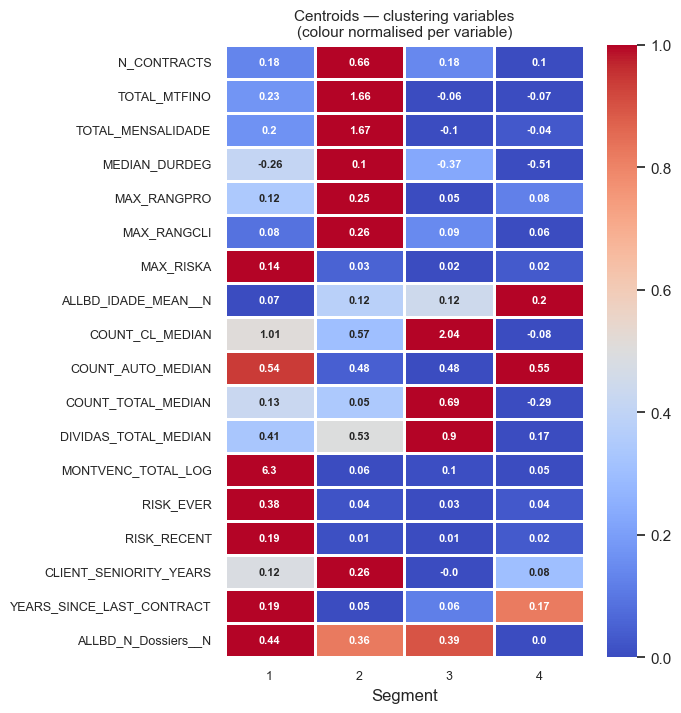

In [15]:
#numeric clutering variables visualization
fig, ax = plt.subplots(figsize=(7, len(all_feature_cols) * 0.35 + 1))

centroids_normalized = centroids_seg.copy()
for col in centroids_seg.columns:
    row = centroids_seg[col]
    row_min, row_max = row.min(), row.max()
    if row_max - row_min > 0:
        centroids_normalized[col] = (row - row_min) / (row_max - row_min)
    else:
        centroids_normalized[col] = 0.5

sns.heatmap(centroids_normalized.T, annot=centroids_seg.T.round(2),
            fmt='', cmap='coolwarm', vmin=0, vmax=1,
            ax=ax, linewidths=0.8, linecolor='white',
            annot_kws={'size': 8,'weight': 'bold'})
ax.set_title('Centroids — clustering variables\n(colour normalised per variable)', fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=9)
ax.set_xlabel('Segment')
plt.tight_layout()
plt.show()

The heatmap displays the mean centroid value for each clustering variable per segment, with colours normalised per row (0 = minimum, 1 = maximum across segments) to highlight relative differences.

**Cluster 1, High Risk / Overdue**
Defined almost exclusively by `MONTVENC_TOTAL_LOG = 6.30`, by far the highest value across all variables and segments. `RISK_EVER = 0.38` and `RISK_RECENT = 0.19` confirm active and recent delinquency. `MAX_RISKA = 0.14` is the highest across segments. This segment is structurally separated from the others by its overdue exposure.

**Cluster 2, High Value**
Characterised by the highest financial activity: `TOTAL_MTFINO = 1.66`, `TOTAL_MENSALIDADE = 1.67` and `N_CONTRACTS = 0.66`, all the highest across segments. `MAX_RANGPRO = 0.25` and 
`MAX_RANGCLI = 0.26` are also the highest across clusters, indicating that these clients have both a higher history of payment delays and a higher number of resolved regularisations, consistent with financially active clients who occasionally miss payments but tend to regularise them. `CLIENT_SENIORITY_YEARS = 0.26` shows they are also the most tenured clients.

**Cluster 3, High External Credit**
Defined by `COUNT_CL_MEDIAN = 2.04` and `COUNT_TOTAL_MEDIAN = 0.69`, these are the ones with the highest external credit activity. `DIVIDAS_TOTAL_MEDIAN = 0.90` confirms significant external debt. `MEDIAN_DURDEG = -0.37` suggests shorter contracts at Cetelem, consistent with clients who spread credit across multiple providers.

**Cluster 4, Base / Dormant**
All values near zero or negative. `MEDIAN_DURDEG = -0.51`: the shortest contracts. `YEARS_SINCE_LAST_CONTRACT = 0.17`, the longest time without a new contract. `ALLBD_N_Dossiers__N ≈ 0`, minimal engagement history. This is the standard, low-engagement client base.

Text(0.5, 33.249999999999986, 'Segment')

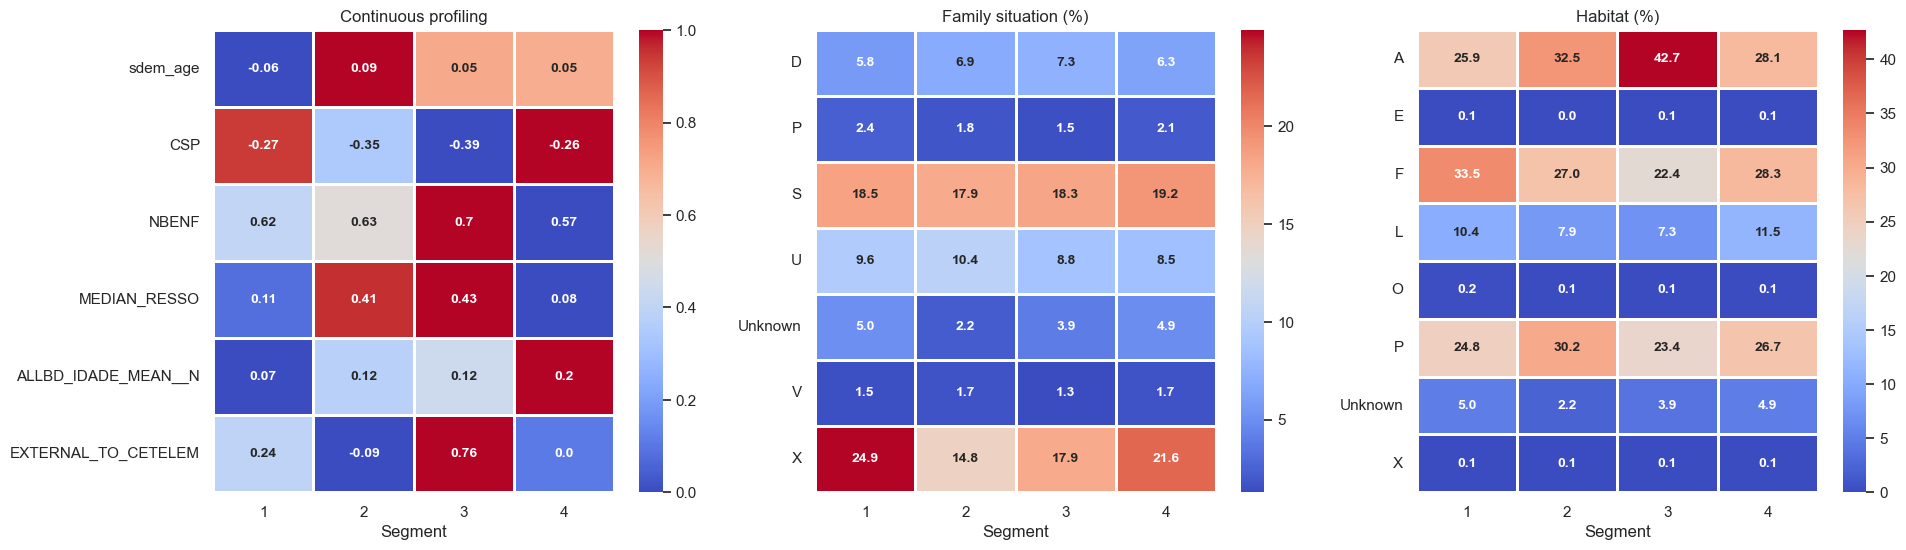

In [16]:
# ── Plot 2 — Continuous profiling + Family situation + Habitat ────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Continuous profiling
available = [c for c in continuous_profiling if c in valid.columns]
profiling_means = valid.groupby(seg_col)[available].mean().round(3)
profiling_normalized = profiling_means.copy()
for col in profiling_means.columns:
    row = profiling_means[col]
    row_min, row_max = row.min(), row.max()
    if row_max - row_min > 0:
        profiling_normalized[col] = (row - row_min) / (row_max - row_min)
    else:
        profiling_normalized[col] = 0.5

sns.heatmap(profiling_normalized.T, annot=profiling_means.T.round(2),
            fmt='', cmap='coolwarm', vmin=0, vmax=1,
            ax=axes[0], linewidths=0.8, linecolor='white',
            annot_kws={'size': 10, 'weight': 'bold'})
axes[0].set_title('Continuous profiling')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)
axes[0].set_xlabel('Segment')

# Family situation
sns.heatmap(sitfam_profile.T, annot=True, fmt='.1f', cmap='coolwarm',
            ax=axes[1], linewidths=0.8, linecolor='white',
            annot_kws={'size': 10, 'weight': 'bold'})
axes[1].set_title('Family situation (%)')
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)
axes[1].set_xlabel('Segment')

# Habitat
sns.heatmap(habitat_profile.T, annot=True, fmt='.1f', cmap='coolwarm',
            ax=axes[2], linewidths=0.8, linecolor='white',
            annot_kws={'size': 10, 'weight': 'bold'})
axes[2].set_title('Habitat (%)')
axes[2].set_yticklabels(axes[2].get_yticklabels(), rotation=0)
axes[2].set_xlabel('Segment')

*Continuous profiling*

- **`sdem_age`** — Cluster 2 (High Value) is marginally older (0.09) while Cluster 1 (High Risk) is the youngest (-0.06). 

- **`CSP`** — All clusters show negative values, with Cluster 3 the lowest (-0.39). Differences are small and CSP alone has limited discriminative power.

- **`NBENF`** — Cluster 3 has the most dependents (0.70), Cluster 4 the fewest (0.57). 

- **`MEDIAN_RESSO`** — The most discriminative variable in this section. Clusters 2 and 3 show clearly higher income (0.41 and 0.43) compared to Clusters 1 and 4 (0.11 and 0.08). This confirms that high-risk and base clients have lower income, while high-value and high-external-credit clients are financially stronger.

- **`ALLBD_IDADE_MEAN__N`** — Cluster 4 shows the oldest average contract age (0.20), suggesting clients with longer-standing credit histories. Differences across clusters are small.

- **`EXTERNAL_TO_CETELEM`** — Cluster 3 stands out clearly (0.76), confirming its defining characteristic: high external credit relative to Cetelem contracts. Cluster 2 is negative (-0.09), indicating that high-value clients are more concentrated in Cetelem products.


*Family situation*

Differences across clusters are modest. The most notable pattern is **SITFAM X (unknown)**, which is highest in Cluster 1 (24.9%) and lowest in Cluster 2 (14.8%). **SITFAM S (single)** is consistently the largest category across all clusters (~18-19%).


*Habitat*

**Cluster 3 (High External Credit)** is the most urban cluster, with the highest proportion in habitat **A (42.7%)** (urban areas) and the lowest in **F (22.4%)**, rural areas. This is consistent with urban clients having greater access to competing credit providers. **Cluster 1 (High Risk)** shows the highest rural concentration (**F = 33.5%**), suggesting that high-risk clients are more concentrated outside urban centres.

### 3.1 Cluster Visualization

UMAP (Uniform Manifold Approximation and Projection) was applied to the 11 most discriminative clustering variables to provide a two-dimensional visualisation of the cluster structure (`n_neighbors=15`, `min_dist=0.05`, sample of 20,000 clients).

Running UMAP...


c:\Users\Asus\anaconda3\envs\Fall2526\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


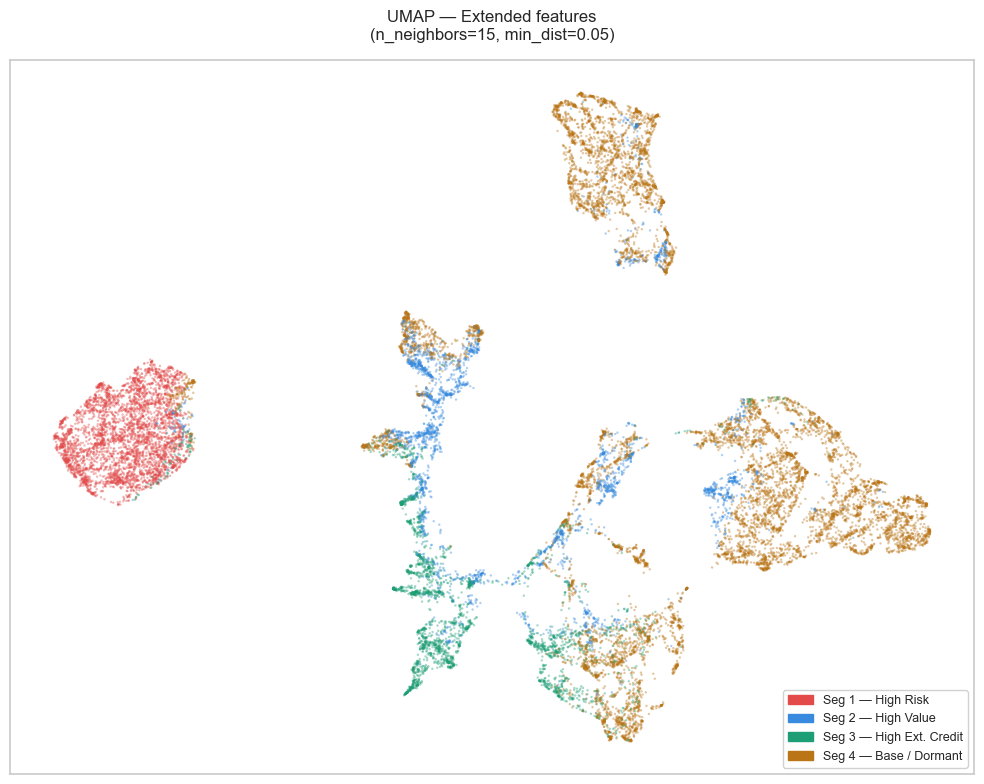

In [17]:
import umap.umap_ as umap_module

# ── Configuration ─────────────────────────────────────────────────────────────
viz_cols_extended = [
    'TOTAL_MTFINO',
    'N_CONTRACTS',
    'MEDIAN_DURDEG',
    'MONTVENC_TOTAL_LOG',
    'COUNT_CL_MEDIAN',
    'DIVIDAS_TOTAL_MEDIAN',
    'RISK_EVER',
    'RISK_RECENT',
    'ALLBD_N_Dossiers__N',
    'CLIENT_SENIORITY_YEARS',
    'YEARS_SINCE_LAST_CONTRACT'
]

segment_colors = {1: '#E24B4A', 2: '#378ADD', 3: '#1D9E75', 4: '#BA7517'}
segment_names  = {
    1: 'Seg 1 — High Risk',
    2: 'Seg 2 — High Value',
    3: 'Seg 3 — High Ext. Credit',
    4: 'Seg 4 — Base / Dormant'
}

# ── Sample ────────────────────────────────────────────────────────────────────
df_viz = customer[viz_cols_extended + ['segment_final']].dropna()
df_sample = df_viz.sample(n=min(20000, len(df_viz)), random_state=42)

X = df_sample[viz_cols_extended].values
colors = df_sample['segment_final'].map(segment_colors).values

legend_patches = [
    mpatches.Patch(color=c, label=segment_names[s])
    for s, c in segment_colors.items()
]

# ── UMAP ──────────────────────────────────────────────────────────────────────
print("Running UMAP...")
reducer = umap_module.UMAP(n_components=2, random_state=42,
                           n_neighbors=15, min_dist=0.05)
X_umap = reducer.fit_transform(X)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(X_umap[:, 0], X_umap[:, 1],
           c=colors, alpha=0.4, s=3, linewidths=0)
ax.set_title('UMAP — Extended features\n(n_neighbors=15, min_dist=0.05)',
             fontsize=12, pad=15)
ax.set_xticks([])
ax.set_yticks([])
ax.legend(handles=legend_patches, loc='lower right',
          fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

**Cluster 1 (High Risk)** completely isolated on the left, forming a compact and well-defined region. This confirms that clients with significant overdue amounts are genuinely distinct from all others in the feature space. It's the most robust cluster of the four.

**Cluster 4 (Base/Dormant)** forms two separate clouds (top and right), reflecting internal sub-structure that the hierarchical merge could not further subdivide given the available variables.

**Cluster 3 (High External Credit)** — visible in the centre/lower region with moderate separation, consistent with its silhouette score.

**Cluster 2 (High Value)** — dispersed across the central region with partial overlap with Clusters 3 and 4, reflecting the lower silhouette score of P1 (Financial) and confirming that the boundary between high-value and base clients is gradual rather than sharp.

> The partial overlap between Clusters 2 and 4 is expected and honest. These two clusters share similar risk profiles and are differentiated primarily by financial volume and contract history rather than by fundamentally different behaviours.

## 4. Churn & Early Settlement Analysis by Cluster

Having characterised each cluster demographically and financially, we now connect them to the two business objectives defined by Cetelem: **Objective 1**: identifying clients who settle early (SAN), and **Objective 2**: identifying clients who do not renew their contract after settlement (churn).

In [18]:
abt = io.load(ABT_OUT_PATH)

[LOAD] ../data/prepared/abt.parquet | shape: (148729, 88)


In [19]:
# ── Merge targets from ABT ────────────────────────────────────────────────────
# Define target columns first
target_columns = [
    'EVER_SOL', 'N_SOL', 
    'EVER_SAN', 'N_SAN', 
    'EVER_RBT', 'N_RBT', 
    'IS_EARLY_SETTLER', 'IS_CHURN'
]

customer_with_targets = customer.merge(
    abt[['CONTRIB'] + target_columns],
    on='CONTRIB',
    how='left'
)

# Create churn types
customer_with_targets['CHURN_EARLY'] = customer_with_targets['IS_EARLY_SETTLER']
customer_with_targets['CHURN_NATURAL'] = (
    (customer_with_targets['EVER_SOL'] == 1) & 
    (customer_with_targets['IS_EARLY_SETTLER'] == 0)
).astype(int)

print(f"Merged dataset: {len(customer_with_targets):,} clients")
print(f"Missing IS_CHURN after merge: {customer_with_targets['IS_CHURN'].isna().sum():,}")

# ── Objective 1 — Early Settlement (SAN) ─────────────────────────────────────
print("\n" + "=" * 60)
print("OBJECTIVE 1 — Early Settlement (SAN)")
print("=" * 60)

obj1 = customer_with_targets.groupby('segment_final').agg(
    n_clients          = ('IS_EARLY_SETTLER', 'count'),
    early_settler_rate = ('IS_EARLY_SETTLER', 'mean'),
    avg_n_san          = ('N_SAN', 'mean'),
).round(3)
obj1['early_settler_pct'] = (obj1['early_settler_rate'] * 100).round(1)

print(f"{'Segment':>8} {'N Clients':>10} {'Early Settler%':>15} {'Avg N_SAN':>10}")
print("-" * 48)
for seg, row in obj1.iterrows():
    print(f"  {int(seg):>6} {row['n_clients']:>10,} "
          f"{row['early_settler_pct']:>14.1f}% "
          f"{row['avg_n_san']:>10.2f}")

# ── Objective 2 — Churn ───────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("OBJECTIVE 2 — Churn (no new contract after settlement)")
print("=" * 60)

obj2 = customer_with_targets.groupby('segment_final').agg(
    n_clients     = ('IS_CHURN', 'count'),
    churn_rate    = ('IS_CHURN', 'mean'),
    churn_early   = ('CHURN_EARLY', 'mean'),
    churn_natural = ('CHURN_NATURAL', 'mean'),
).round(3)

for col in ['churn_rate', 'churn_early', 'churn_natural']:
    obj2[col] = (obj2[col] * 100).round(1)

print(f"{'Segment':>8} {'N Clients':>10} {'Churn%':>8} "
      f"{'Early%':>8} {'Natural%':>10}")
print("-" * 50)
for seg, row in obj2.iterrows():
    print(f"  {int(seg):>6} {row['n_clients']:>10,} "
          f"{row['churn_rate']:>7.1f}% "
          f"{row['churn_early']:>7.1f}% "
          f"{row['churn_natural']:>9.1f}%")

Merged dataset: 134,222 clients
Missing IS_CHURN after merge: 0

OBJECTIVE 1 — Early Settlement (SAN)
 Segment  N Clients  Early Settler%  Avg N_SAN
------------------------------------------------
       1   26,745.0           25.5%       0.28
       2   21,098.0           46.6%       0.63
       3   18,766.0           26.9%       0.29
       4   67,613.0           22.8%       0.24

OBJECTIVE 2 — Churn (no new contract after settlement)
 Segment  N Clients   Churn%   Early%   Natural%
--------------------------------------------------
       1   26,745.0    36.7%    25.5%      11.8%
       2   21,098.0    51.9%    46.6%       7.4%
       3   18,766.0    38.4%    26.9%      12.0%
       4   67,613.0    43.5%    22.8%      21.1%


### 4.1 Objective 1 | Early Settlement Analysis

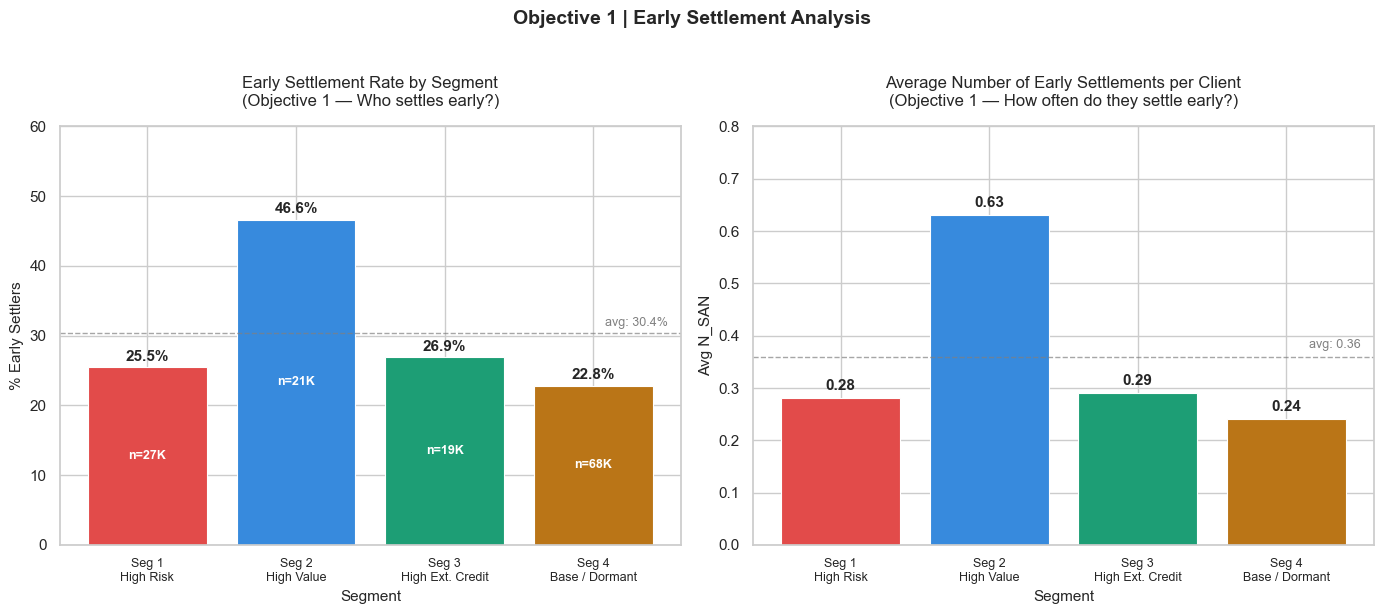

In [20]:
# ── Data ──────────────────────────────────────────────────────────────────────
segments = ['Seg 1\nHigh Risk', 'Seg 2\nHigh Value', 
            'Seg 3\nHigh Ext. Credit', 'Seg 4\nBase / Dormant']
early_pct = [25.5, 46.6, 26.9, 22.8]
avg_nsan  = [0.28, 0.63, 0.29, 0.24]
n_clients = [26745, 21098, 18766, 67613]
colors    = ['#E24B4A', '#378ADD', '#1D9E75', '#BA7517']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Chart 1 — Early Settler Rate ──────────────────────────────────────────────
bars = axes[0].bar(segments, early_pct, color=colors, 
                   edgecolor='white', linewidth=0.8)

# Annotate bars
for bar, pct, n in zip(bars, early_pct, n_clients):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{pct:.1f}%', ha='center', va='bottom', 
                fontsize=11, fontweight='bold')
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                f'n={n/1000:.0f}K', ha='center', va='center',
                fontsize=9, color='white', fontweight='bold')

axes[0].set_title('Early Settlement Rate by Segment\n(Objective 1 — Who settles early?)', 
                  fontsize=12, pad=15)
axes[0].set_ylabel('% Early Settlers', fontsize=11)
axes[0].set_ylim(0, 60)
axes[0].axhline(y=sum(early_pct)/len(early_pct), color='gray', 
                linestyle='--', linewidth=1, alpha=0.7)
axes[0].text(3.5, sum(early_pct)/len(early_pct) + 0.5, 
             f'avg: {sum(early_pct)/len(early_pct):.1f}%',
             ha='right', va='bottom', fontsize=9, color='gray')
axes[0].set_xlabel('Segment', fontsize=11)
axes[0].tick_params(axis='x', labelsize=9)

# ── Chart 2 — Avg N_SAN ───────────────────────────────────────────────────────
bars2 = axes[1].bar(segments, avg_nsan, color=colors,
                    edgecolor='white', linewidth=0.8)

for bar, val in zip(bars2, avg_nsan):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom',
                fontsize=11, fontweight='bold')

axes[1].set_title('Average Number of Early Settlements per Client\n(Objective 1 — How often do they settle early?)',
                  fontsize=12, pad=15)
axes[1].set_ylabel('Avg N_SAN', fontsize=11)
axes[1].set_ylim(0, 0.80)
axes[1].axhline(y=sum(avg_nsan)/len(avg_nsan), color='gray',
                linestyle='--', linewidth=1, alpha=0.7)
axes[1].text(3.5, sum(avg_nsan)/len(avg_nsan) + 0.01,
             f'avg: {sum(avg_nsan)/len(avg_nsan):.2f}',
             ha='right', va='bottom', fontsize=9, color='gray')
axes[1].set_xlabel('Segment', fontsize=11)
axes[1].tick_params(axis='x', labelsize=9)

plt.suptitle('Objective 1 | Early Settlement Analysis', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Cluster 2 (High Value)** is the dominant early settlement cluster by a substantial margin. With a rate of **46.6%**, more than **1.5× the dataset average (30.4%)** and an average of **0.63 early settlements per client** (vs avg 0.36), these clients settle early both more frequently and more consistently than any other cluster. This is consistent with their financial profile: higher income and multiple contracts. These are clients wh are both financially capable and motivated to 
exit early, consistent with the EDA finding that early settlers take out larger loans but plan an early exit, possibly triggered by year-end bonus payments or refinancing opportunities.

**Clusters 1, 3 and 4** all fall below the dataset average, ranging between 22.8% and 26.9%:

- **Cluster 1 (High Risk, 25.5%)** — early settlement despite financial stress. These clients may be settling to resolve existing delinquency and avoid further financial penalties, rather than acting from a position of financial strength.
- **Cluster 3 (High Ext. Credit, 26.9%)** — moderate early settlement, consistent with clients who manage multiple credit products actively and may consolidate debt across providers.
- **Cluster 4 (Base/Dormant, 22.8%)** — the lowest rate, consistent with passive clients who tend to complete contracts at maturity rather than act proactively.

> **Key insights:** Early settlement is almost exclusively a Cluster 2 phenomenon. Interventions targeting early settlement prevention should be concentrated on this cluster, ideally at **25–50% of contract lifecycle**, before the settlement decision is made.

### 4.2 Objective 2 | Churn Analysis

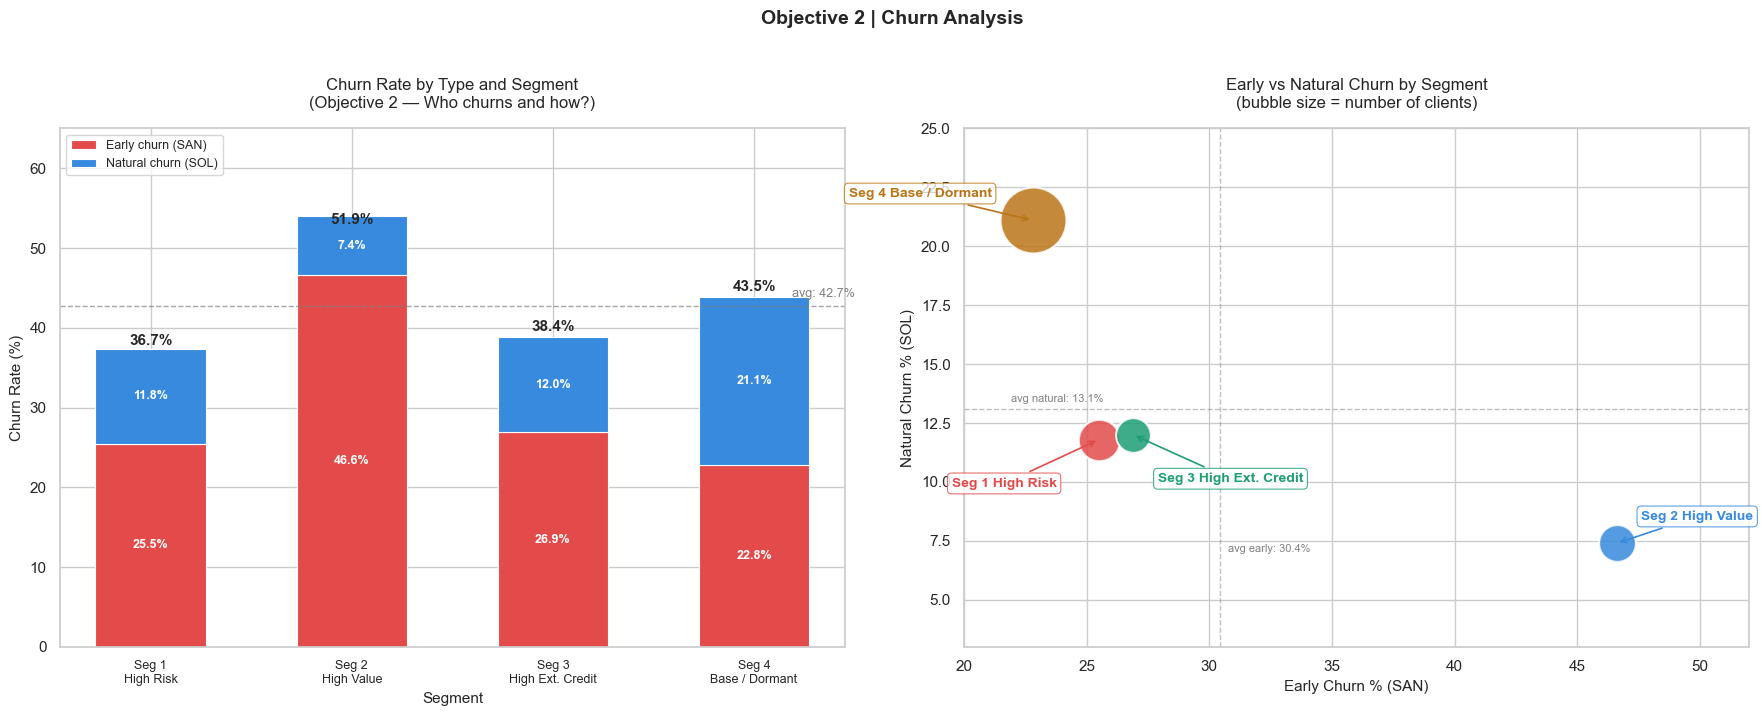

In [21]:
# ── Data — Objective 2 ────────────────────────────────────────────────────────
segments      = ['Seg 1\nHigh Risk', 'Seg 2\nHigh Value',
                 'Seg 3\nHigh Ext. Credit', 'Seg 4\nBase / Dormant']
colors        = ['#E24B4A', '#378ADD', '#1D9E75', '#BA7517']
n_clients     = [26745, 21098, 18766, 67613]
churn_total   = [36.7, 51.9, 38.4, 43.5]
churn_early   = [25.5, 46.6, 26.9, 22.8]
churn_natural = [11.8,  7.4, 12.0, 21.1]

x     = np.arange(len(segments))
width = 0.55

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Chart 1 — Stacked bar ─────────────────────────────────────────────────────
bars_early = axes[0].bar(x, churn_early, width,
                          label='Early churn (SAN)',
                          color='#E24B4A', edgecolor='white', linewidth=0.8)
bars_natural = axes[0].bar(x, churn_natural, width,
                            bottom=churn_early,
                            label='Natural churn (SOL)',
                            color='#378ADD', edgecolor='white', linewidth=0.8)

for i, (total, n) in enumerate(zip(churn_total, n_clients)):
    axes[0].text(i, total + 0.8, f'{total:.1f}%',
                ha='center', va='bottom',
                fontsize=11, fontweight='bold')
    axes[0].text(i, churn_early[i]/2, f'{churn_early[i]:.1f}%',
                ha='center', va='center',
                fontsize=9, color='white', fontweight='bold')
    axes[0].text(i, churn_early[i] + churn_natural[i]/2,
                f'{churn_natural[i]:.1f}%',
                ha='center', va='center',
                fontsize=9, color='white', fontweight='bold')

axes[0].set_title('Churn Rate by Type and Segment\n(Objective 2 — Who churns and how?)',
                  fontsize=12, pad=15)
axes[0].set_ylabel('Churn Rate (%)', fontsize=11)
axes[0].set_ylim(0, 65)
axes[0].set_xticks(x)
axes[0].set_xticklabels(segments, fontsize=9)
axes[0].axhline(y=42.7, color='gray', linestyle='--',
                linewidth=1, alpha=0.7)
axes[0].text(3.5, 43.5, 'avg: 42.7%', ha='right',
             va='bottom', fontsize=9, color='gray')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].set_xlabel('Segment', fontsize=11)

# ── Chart 2 — Scatter (larger, no overlapping labels) ────────────────────────
# Manual label offsets to avoid overlap
label_offsets = [
    (-60, -20),   # Seg 1 High Risk — left
    ( 10,  10),   # Seg 2 High Value — right
    ( 10, -20),   # Seg 3 High Ext. Credit — right below
    (-75,  10),   # Seg 4 Base / Dormant — left above
]

for i, (seg, early, natural, n, color, offset) in enumerate(
    zip(segments, churn_early, churn_natural, n_clients, colors, label_offsets)):

    axes[1].scatter(early, natural, s=n/30, color=color,
                   alpha=0.85, edgecolors='white', linewidth=1.5, zorder=3)

    # Arrow from label to point
    axes[1].annotate(
        seg.replace('\n', ' '),
        xy=(early, natural),
        xytext=(early + offset[0]/10, natural + offset[1]/10),
        fontsize=10, color=color, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=color, lw=1.2),
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                  edgecolor=color, alpha=0.8, linewidth=0.8)
    )

axes[1].set_xlabel('Early Churn % (SAN)', fontsize=11)
axes[1].set_ylabel('Natural Churn % (SOL)', fontsize=11)
axes[1].set_title('Early vs Natural Churn by Segment\n(bubble size = number of clients)',
                  fontsize=12, pad=15)

# Average lines
avg_early   = sum(churn_early) / len(churn_early)
avg_natural = sum(churn_natural) / len(churn_natural)
axes[1].axvline(x=avg_early, color='gray', linestyle='--', 
                linewidth=1, alpha=0.5)
axes[1].axhline(y=avg_natural, color='gray', linestyle='--', 
                linewidth=1, alpha=0.5)
axes[1].text(avg_early + 0.3, axes[1].get_ylim()[0] + 0.3,
             f'avg early: {avg_early:.1f}%', fontsize=8, color='gray')
axes[1].text(axes[1].get_xlim()[0] + 0.3, avg_natural + 0.3,
             f'avg natural: {avg_natural:.1f}%', fontsize=8, color='gray')

# Add padding around points
axes[1].set_xlim(20, 52)
axes[1].set_ylim(3, 25)

plt.suptitle('Objective 2 | Churn Analysis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Stacked bar (left)** shows total churn rate decomposed into early churn (SAN, red) and natural churn (SOL, blue) for each cluster.

**Cluster 2 (High Value)** has the highest overall churn at **51.9%**, driven almost entirely by early churn (46.6% red vs 7.4% blue). These clients exit proactively before contract end. This is the most concerning group for Cetelem given their high financial value.

**Cluster 4 (Base/Dormant)** sits above the dataset average (43.5%) with a markedly different churn composition. Natural churn dominates (21.1% blue vs 22.8% red). These clients complete their contracts but do not renew, representing passive exits that are harder to prevent without proactive engagement.

**Clusters 1 and 3** both fall below the average (36.7% and 38.4%) with a balanced mix of early and natural churn, suggesting no single dominant exit mechanism.


**Scatter plot (right)** maps each cluster by its early vs natural churn rates, with bubble size proportional to number of clients.

The chart reveals a clear structural split across two axes:

- **Cluster 2 (bottom right)** — extreme early churn, low natural churn. Far beyond the average on the horizontal axis (46.6% vs avg 30.4%). The smallest bubble but the highest financial impact.
- **Cluster 4 (top left)** — high natural churn, low early churn. The largest bubble, positioned well above the average natural churn line (21.1% vs avg 13.1%).
- **Clusters 1 and 3 (centre)** — both close to the intersection of the two average lines, confirming a mixed and moderate churn profile.

> **Key insight:** The two dominant churn mechanisms require fundamentally different interventions. Cluster 2 requires **proactive mid-contract outreach** before the early settlement decision, while Cluster 4 requires **end-of-contract renewal campaigns** before the natural exit point.

### 4.3 Intervention Strategy | Lifecycle & Timing

Having established *who* churns and *how*, we now address *when* to intervene. By combining the lifecycle position of each cluster with its churn type, LTI and proportion of clients in critical contract stages, we define a targeted intervention window for each segment — translating the clustering output into a concrete retention roadmap for Cetelem.

In [22]:
# ── Lifecycle & LTI Analysis ──────────────────────────────────────────────────

# Merge original unscaled values from ABT
customer_with_targets = customer.merge(
    abt[['CONTRIB'] + target_columns + 
        ['FIRST_DCREAT', 'LAST_DCREAT', 'MEDIAN_DURDEG', 
         'TOTAL_MTFINO', 'MEDIAN_RESSO']],
    on='CONTRIB',
    how='left'
)

# Create churn types
customer_with_targets['CHURN_EARLY'] = customer_with_targets['IS_EARLY_SETTLER']
customer_with_targets['CHURN_NATURAL'] = (
    (customer_with_targets['EVER_SOL'] == 1) & 
    (customer_with_targets['IS_EARLY_SETTLER'] == 0)
).astype(int)

# Reference date
ref_date = pd.Timestamp('2025-11-30')  # adjust if needed

# Seniority and recency from original dates
customer_with_targets['CLIENT_SENIORITY_YEARS_ORIG'] = (
    ref_date - pd.to_datetime(customer_with_targets['FIRST_DCREAT'])
).dt.days / 365.25

customer_with_targets['YEARS_SINCE_LAST_CONTRACT_ORIG'] = (
    ref_date - pd.to_datetime(customer_with_targets['LAST_DCREAT'])
).dt.days / 365.25

# Lifecycle stage — _y = original unscaled from ABT
customer_with_targets['LIFECYCLE_STAGE'] = (
    customer_with_targets['YEARS_SINCE_LAST_CONTRACT_ORIG'] * 12 /
    (customer_with_targets['MEDIAN_DURDEG_y'] + 1e-6)
).clip(0, 1)

# LTI — _y = original unscaled from ABT
customer_with_targets['LTI'] = np.where(
    customer_with_targets['MEDIAN_RESSO_y'] > 0,
    customer_with_targets['TOTAL_MTFINO_y'] / 
    customer_with_targets['MEDIAN_RESSO_y'],
    np.nan
)

# ── Results ───────────────────────────────────────────────────────────────────
print("=" * 65)
print("SEGMENT INSIGHTS — LIFECYCLE & LTI")
print("=" * 65)

results = customer_with_targets.groupby('segment_final').agg(
    n_clients          = ('IS_CHURN', 'count'),
    churn_rate         = ('IS_CHURN', 'mean'),
    early_settler_rate = ('IS_EARLY_SETTLER', 'mean'),
    lifecycle_mean     = ('LIFECYCLE_STAGE', 'mean'),
    pct_final_quarter  = ('LIFECYCLE_STAGE', lambda x: (x > 0.75).mean()),
    pct_mid_contract   = ('LIFECYCLE_STAGE',
                          lambda x: ((x >= 0.25) & (x <= 0.75)).mean()),
    lti_mean           = ('LTI', 'mean'),
).round(3)

for col in ['churn_rate', 'early_settler_rate',
            'lifecycle_mean', 'pct_final_quarter', 'pct_mid_contract']:
    results[col] = (results[col] * 100).round(1)
results['lti_mean'] = results['lti_mean'].round(2)

print(f"\n{'Metric':<25} {'Seg 1':>8} {'Seg 2':>8} {'Seg 3':>8} {'Seg 4':>8}")
print(f"{'':25} {'High Risk':>8} {'Hi Value':>8} {'Hi Ext.':>8} {'Base':>8}")
print("-" * 65)

metrics = {
    'N clients':           'n_clients',
    'Churn rate (%)':      'churn_rate',
    'Early settler (%)':   'early_settler_rate',
    'Lifecycle stage (%)': 'lifecycle_mean',
    'Final quarter (%)':   'pct_final_quarter',
    'Mid-contract (%)':    'pct_mid_contract',
    'LTI':                 'lti_mean',
}

for label, col in metrics.items():
    print(f"  {label:<23}", end='')
    for seg in [1, 2, 3, 4]:
        val = results.loc[seg, col]
        print(f"  {val:>8}", end='')
    print()

print("\nEDA reference:")
print("  LTI           → early settlers mean=11, non-settlers mean=8")
print("  Final quarter → churn rate 92.4%")
print("  Mid-contract  → early settlement concentrated here (25-75%)")

SEGMENT INSIGHTS — LIFECYCLE & LTI

Metric                       Seg 1    Seg 2    Seg 3    Seg 4
                          High Risk Hi Value  Hi Ext.     Base
-----------------------------------------------------------------
  N clients                   26745     21098     18766     67613
  Churn rate (%)               36.7      51.9      38.4      43.5
  Early settler (%)            25.5      46.6      26.9      22.8
  Lifecycle stage (%)          53.5      36.8      48.6      56.4
  Final quarter (%)            28.1      11.4      24.4      36.7
  Mid-contract (%)             48.5      44.8      45.7      37.3
  LTI                         16.26     24.04      8.36       8.6

EDA reference:
  LTI           → early settlers mean=11, non-settlers mean=8
  Final quarter → churn rate 92.4%
  Mid-contract  → early settlement concentrated here (25-75%)


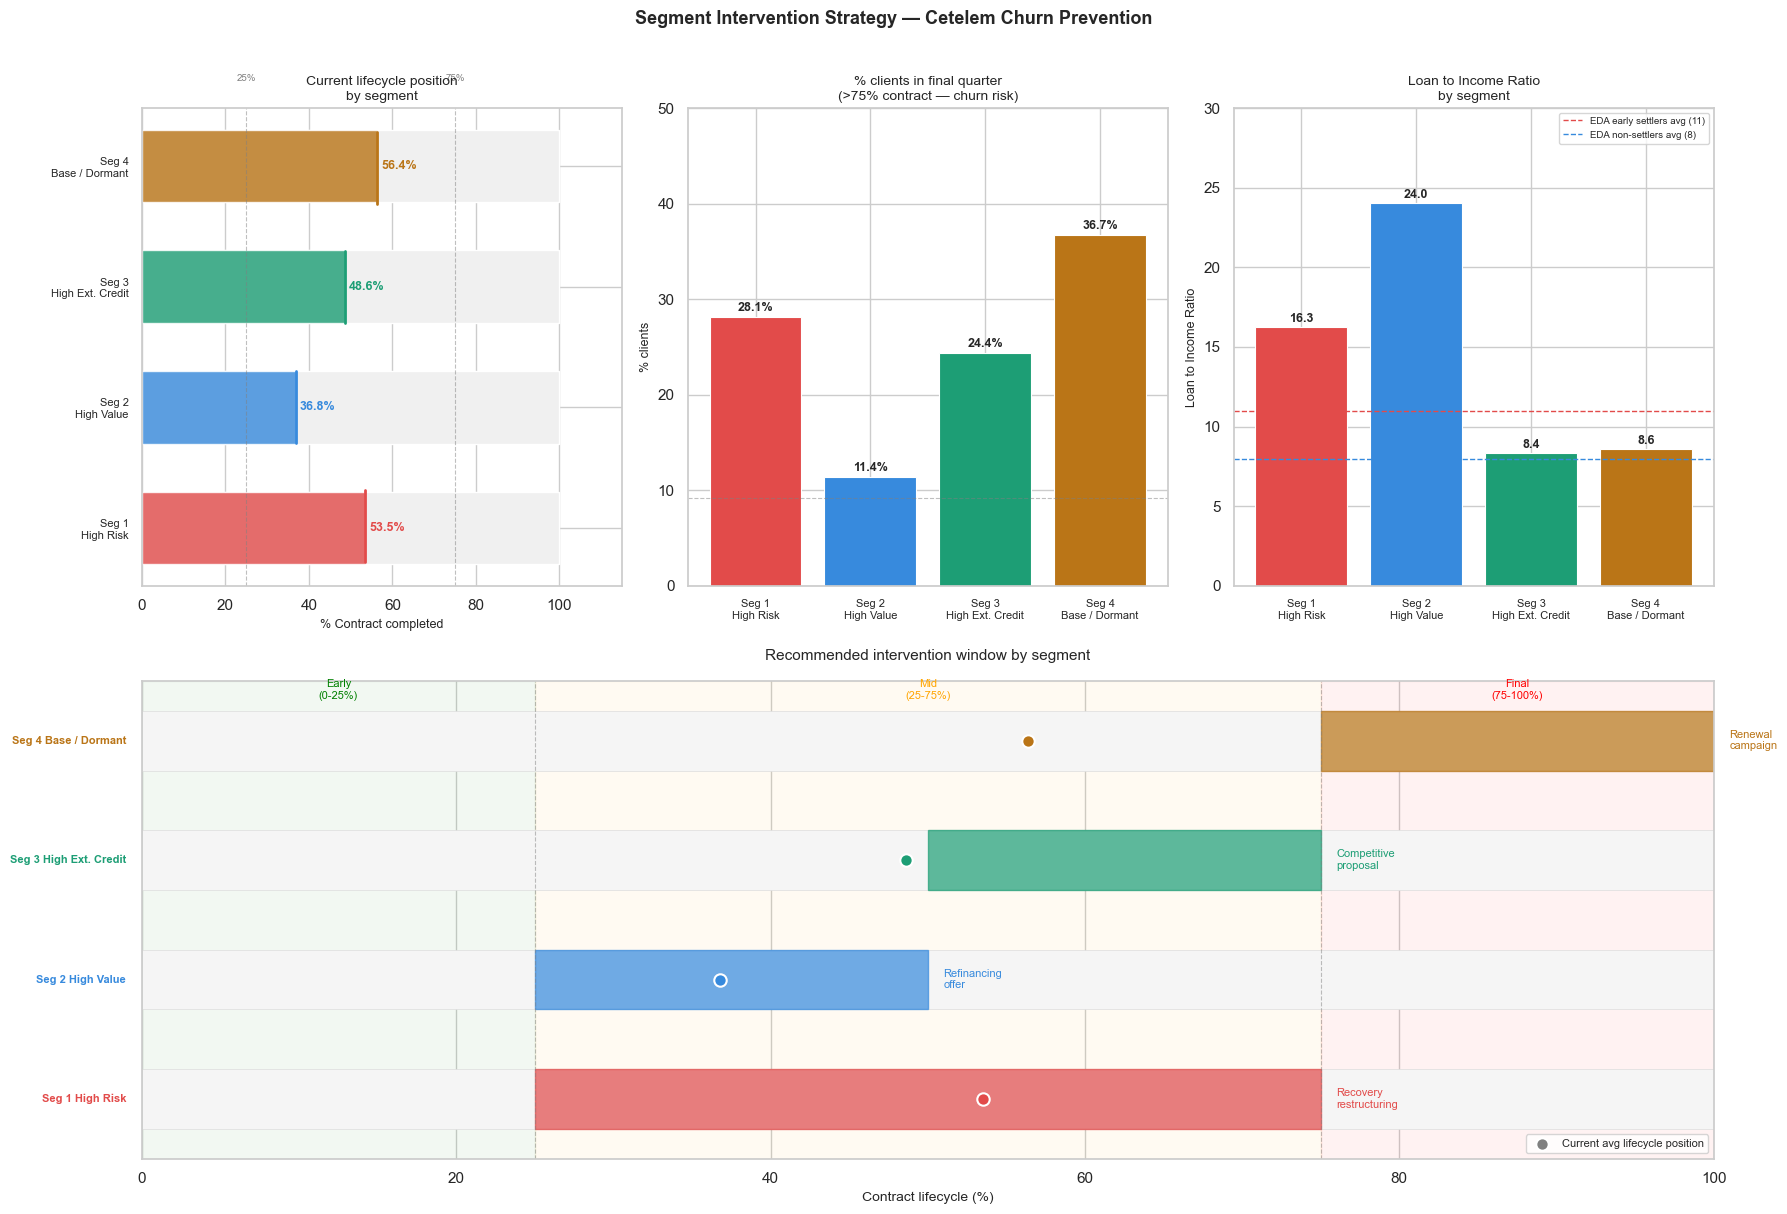

In [23]:
# ── Data ──────────────────────────────────────────────────────────────────────
segments     = ['Seg 1\nHigh Risk', 'Seg 2\nHigh Value',
                'Seg 3\nHigh Ext. Credit', 'Seg 4\nBase / Dormant']
colors       = ['#E24B4A', '#378ADD', '#1D9E75', '#BA7517']
n_clients    = [26745, 21098, 18766, 67613]
churn_rate   = [36.7, 51.9, 38.4, 43.5]
early_pct    = [25.5, 46.6, 26.9, 22.8]
lifecycle    = [53.5, 36.8, 48.6, 56.4]
final_q      = [28.1, 11.4, 24.4, 36.7]
mid_contract = [48.5, 44.8, 45.7, 37.3]
lti          = [16.26, 24.04, 8.36, 8.60]

# Intervention timing per segment
timing = [
    '25–75%\ncontract',   # Seg 1
    '25–50%\ncontract',   # Seg 2
    '50–75%\ncontract',   # Seg 3
    '75–100%\ncontract',  # Seg 4
]

actions = [
    'Recovery\nrestructuring',
    'Refinancing\noffer',
    'Competitive\nproposal',
    'Renewal\ncampaign',
]

fig = plt.figure(figsize=(18, 12))

# ── Chart 1 — Lifecycle position (horizontal bar) ────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)

for i, (seg, lc, color) in enumerate(zip(segments, lifecycle, colors)):
    # Full contract bar
    ax1.barh(i, 100, color='#f0f0f0', edgecolor='white', height=0.6)
    # Lifecycle position
    ax1.barh(i, lc, color=color, alpha=0.8, height=0.6)
    # Vertical line at current position
    ax1.axvline(x=lc, ymin=i/4 + 0.05, ymax=(i+1)/4 - 0.05,
                color=color, linewidth=2)
    ax1.text(lc + 1, i, f'{lc:.1f}%', va='center', fontsize=9,
             fontweight='bold', color=color)

ax1.set_xlim(0, 115)
ax1.set_yticks(range(4))
ax1.set_yticklabels(segments, fontsize=8)
ax1.set_xlabel('% Contract completed', fontsize=9)
ax1.set_title('Current lifecycle position\nby segment', fontsize=10)
ax1.axvline(x=25, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.axvline(x=75, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.text(25, 3.7, '25%', ha='center', fontsize=7, color='gray')
ax1.text(75, 3.7, '75%', ha='center', fontsize=7, color='gray')

# ── Chart 2 — % in final quarter ─────────────────────────────────────────────
ax2 = fig.add_subplot(2, 3, 2)
bars = ax2.bar(range(4), final_q, color=colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, final_q):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9,
             fontweight='bold')
ax2.set_xticks(range(4))
ax2.set_xticklabels(segments, fontsize=8)
ax2.set_ylabel('% clients', fontsize=9)
ax2.set_title('% clients in final quarter\n(>75% contract — churn risk)', fontsize=10)
ax2.set_ylim(0, 50)
ax2.axhline(y=36.7/4*1, color='gray', linestyle='--',
            linewidth=0.8, alpha=0.5)

# ── Chart 3 — LTI ────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(2, 3, 3)
bars3 = ax3.bar(range(4), lti, color=colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars3, lti):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}', ha='center', va='bottom', fontsize=9,
             fontweight='bold')
ax3.axhline(y=11, color='#E24B4A', linestyle='--', linewidth=1,
            label='EDA early settlers avg (11)')
ax3.axhline(y=8, color='#378ADD', linestyle='--', linewidth=1,
            label='EDA non-settlers avg (8)')
ax3.set_xticks(range(4))
ax3.set_xticklabels(segments, fontsize=8)
ax3.set_ylabel('Loan to Income Ratio', fontsize=9)
ax3.set_title('Loan to Income Ratio\nby segment', fontsize=10)
ax3.set_ylim(0, 30)
ax3.legend(fontsize=7)

# ── Chart 4 — Intervention timing ────────────────────────────────────────────
ax4 = fig.add_subplot(2, 1, 2)
ax4.set_xlim(0, 100)
ax4.set_ylim(-0.5, 3.5)
ax4.set_xlabel('Contract lifecycle (%)', fontsize=10)
ax4.set_title('Recommended intervention window by segment', 
              fontsize=11, pad=15)

# Contract lifecycle background zones
ax4.axvspan(0,  25, alpha=0.05, color='green',  label='Early stage')
ax4.axvspan(25, 75, alpha=0.05, color='orange', label='Mid stage')
ax4.axvspan(75, 100, alpha=0.05, color='red',   label='Final stage')
ax4.text(12.5, 3.35, 'Early\n(0-25%)',  ha='center', fontsize=8, color='green')
ax4.text(50,   3.35, 'Mid\n(25-75%)',   ha='center', fontsize=8, color='orange')
ax4.text(87.5, 3.35, 'Final\n(75-100%)',ha='center', fontsize=8, color='red')

# Intervention windows
intervention_windows = [
    (25, 75),   # Seg 1 — High Risk
    (25, 50),   # Seg 2 — High Value
    (50, 75),   # Seg 3 — High Ext. Credit
    (75, 100),  # Seg 4 — Base / Dormant
]

for i, (seg, (start, end), color, lc, action) in enumerate(
    zip(segments, intervention_windows, colors, lifecycle, actions)):

    # Full contract bar background
    ax4.barh(i, 100, left=0, height=0.5, color='#f5f5f5',
             edgecolor='#dddddd', linewidth=0.5)

    # Intervention window
    ax4.barh(i, end-start, left=start, height=0.5, color=color,
             alpha=0.7, edgecolor=color, linewidth=1)

    # Current position marker
    ax4.scatter(lc, i, color=color, s=80, zorder=5,
                edgecolors='white', linewidth=1.5)

    # Labels
    ax4.text(-1, i, seg.replace('\n', ' '),
             ha='right', va='center', fontsize=8,
             fontweight='bold', color=color)
    ax4.text(end + 1, i, action,
             ha='left', va='center', fontsize=8, color=color)

ax4.set_yticks([])
ax4.axvline(x=25, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax4.axvline(x=75, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# Legend for current position
current_pos = plt.scatter([], [], color='gray', s=80,
                          edgecolors='white', linewidth=1.5,
                          label='Current avg lifecycle position')
ax4.legend(handles=[current_pos], loc='lower right', fontsize=8)

plt.suptitle('Segment Intervention Strategy — Cetelem Churn Prevention',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Cluster 2 | High Value → intervene at 25–50% of contract**  
Currently at 36.8% lifecycle already inside the intervention window. With 46.6% early settlement rate and LTI (Loan-to-Income Ratio) = 24, not because of low income (in fact this cluster has the highest income of all) but because it takes out disproportionately larger loans relative to income. This is consistent with the EDA finding that early settlers borrow significantly more on average (€15,751 vs €9,752), reflecting financially sophisticated clients who leverage credit strategically and are both capable and motivated to settle early when the opportunity arises. 44.8% are currently at mid-contract. Intervention here is urgent.

*Recommended action: refinancing offer or new contract proposal before the early settlement decision is made.*

**Cluster 3 | High External Credit → intervene at 50–75% of contract**  
Currently at 48.6% lifecycle, entering the intervention window. LTI=8.36 is close to the non-settler average, suggesting these clients are not driven by financial stress but by availability of competing products. 45.7% are currently at mid-contract.

*Recommended action: competitive proposal addressing external credit market alternatives.*

**Cluster 1 | High Risk → intervene at 25–75% of contract**  
Currently at 53.5% lifecycle, inside the intervention window. LTI=16.26 above both EDA references, with 48.5% at mid-contract and 28.1% already in the final quarter. Despite lower churn (36.7%), the financial stress profile requires immediate attention to prevent both delinquency escalation and exit.  

*Recommended action: recovery restructuring and debt renegotiation.*

**Cluster 4 | Base / Dormant → intervene at 75–100% of contract**  
Currently at 56.4% lifecycle — approaching the intervention window. With 36.7% already in the final quarter and natural churn dominating (21.1%), these clients complete their contracts but do not return. LTI=8.60 confirms no financial pressure — this is a passive exit driven by lack of engagement. 

*Recommended action: renewal campaign in the final quarter, with cross-sell to increase product depth before contract end.*